# Induction Head Ablation Study

Run ablation experiments on candidate induction heads identified in notebook 05.

Tests whether heads that are nearby known GPT-2 induction heads in embedding space
also behave like induction heads when ablated.

## Metrics:
1. **Loss on repeated sequences** - core induction test
2. **Prefix matching score** - attention pattern analysis
3. **In-context learning score** - early vs late loss

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import numpy as np
import torch
from jaxtyping import Int
from torch import Tensor

# attention-motifs ablation
from attention_motifs.ablation import (
    AblationMethod,
    HeadAblator,
    CandidateHeads,
    find_candidate_induction_heads,
    get_control_heads,
    generate_repeated_sequences,
    repeated_sequence_loss,
    prefix_matching_score,
    icl_score,
    run_ablation_experiment,
)
from attention_motifs.ablation.experiment import (
    ExperimentConfig,
    ExperimentResults,
    analyze_results,
    identify_induction_heads,
)
from attention_motifs.ablation.candidates import load_candidates_from_file
from attention_motifs.ablation.ablate import heads_from_strings
from attention_motifs.ablation.data import RepeatedSequence
from attention_motifs.features.analysis import DistanceTensorResult

from transformer_lens import HookedTransformer

In [ ]:
# config
pl.Config.set_tbl_rows(30)
PATH_BASE: Path = Path("../data/")
DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# Load candidates from notebook 05

In [ ]:
# load candidates (or regenerate if needed)
candidates_path: Path = PATH_BASE / "ablation" / "candidates.json"

if candidates_path.exists():
    CANDIDATES: CandidateHeads = load_candidates_from_file(candidates_path)
    print(f"Loaded {len(CANDIDATES.candidates_by_model)} models worth of candidates")
else:
    print("Candidates not found, regenerating...")
    HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.read_raw(PATH_BASE / "features" / "head_dists_raw")
    CANDIDATES = find_candidate_induction_heads(HEAD_DISTS, k_neighbors=20)

In [4]:
# show available models
for model, candidates in CANDIDATES.candidates_by_model.items():
    print(f"{model}: {len(candidates)} candidates")

gpt2-medium: 37 candidates
gemma-2-2b: 7 candidates
Llama-3-2-1B: 33 candidates
pythia-1b: 12 candidates
gemma-2b: 3 candidates


# Sanity check: Verify ablation works on known GPT-2 induction heads

In [ ]:
# load gpt2-small and test known induction heads
model_gpt2: HookedTransformer = HookedTransformer.from_pretrained("gpt2-small", device=DEVICE)

In [ ]:
# generate test sequences
sequences: list[RepeatedSequence] = generate_repeated_sequences(
    tokenizer=model_gpt2.tokenizer,
    n_sequences=50,
    seq_length=25,
    n_repetitions=4,
    seed=42,
    device=DEVICE,
)
print(f"Generated {len(sequences)} test sequences")

In [ ]:
# baseline loss (no ablation)
baseline_loss: float = repeated_sequence_loss(model_gpt2, sequences)
print(f"Baseline loss on repeated sequences: {baseline_loss:.4f}")

In [ ]:
# test ablating known induction heads
KNOWN_INDUCTION_HEADS: list[tuple[int, int]] = [(5, 5), (6, 9), (5, 8), (5, 9)]  # from IOI paper

ablator: HeadAblator = HeadAblator(model_gpt2)

# compute mean activations for mean ablation
calibration_tokens: list[Int[Tensor, "seq_len"]] = [s.tokens for s in sequences[:30]]
ablator.compute_mean_activations(calibration_tokens)

print("\nZero Ablation Results:")
print("-" * 50)
for layer, head in KNOWN_INDUCTION_HEADS:
    with ablator.ablate_heads([(layer, head)], AblationMethod.ZERO):
        ablated_loss = repeated_sequence_loss(model_gpt2, sequences)
    loss_increase = ablated_loss - baseline_loss
    prefix = prefix_matching_score(model_gpt2, layer, head, sequences)
    print(f"L{layer}:H{head}: loss={ablated_loss:.4f} (increase={loss_increase:.4f}), prefix={prefix:.4f}")

In [ ]:
# compare to ablating non-induction heads
NON_INDUCTION_HEADS: list[tuple[int, int]] = [(0, 0), (1, 1), (2, 2), (11, 11)]  # random heads

print("\nNon-Induction Heads (control):")
print("-" * 50)
for layer, head in NON_INDUCTION_HEADS:
    with ablator.ablate_heads([(layer, head)], AblationMethod.ZERO):
        ablated_loss = repeated_sequence_loss(model_gpt2, sequences)
    loss_increase = ablated_loss - baseline_loss
    prefix = prefix_matching_score(model_gpt2, layer, head, sequences)
    print(f"L{layer}:H{head}: loss={ablated_loss:.4f} (increase={loss_increase:.4f}), prefix={prefix:.4f}")

# Run full experiment on candidate model

In [ ]:
# select model to test (change this to test different models)
TARGET_MODEL: str = "pythia-1b"  # or "gemma-2b", etc.

# get candidates and controls
model_candidates: list[tuple[str, float]] = CANDIDATES.get_top_candidates(TARGET_MODEL, n=10)
print(f"Top 10 candidates for {TARGET_MODEL}:")
for head, score in model_candidates:
    print(f"  {head}: {score:.3f}")

In [ ]:
# run experiment
config: ExperimentConfig = ExperimentConfig(
    n_sequences=100,
    seq_length=25,
    n_repetitions=4,
    ablation_methods=[AblationMethod.ZERO, AblationMethod.MEAN],
    seed=42,
)

candidate_heads: list[str] = [h for h, _ in model_candidates]

# get control heads from distance matrix
HEAD_DISTS: DistanceTensorResult = DistanceTensorResult.read_raw(PATH_BASE / "features" / "head_dists_raw")
control_heads: list[str] = get_control_heads(HEAD_DISTS, CANDIDATES, TARGET_MODEL, n_controls=5, method="far")

print(f"\nControl heads: {control_heads}")

In [ ]:
# run the experiment
results: ExperimentResults = run_ablation_experiment(
    model_name=TARGET_MODEL,
    candidate_heads=candidate_heads,
    control_heads=control_heads,
    config=config,
    device=DEVICE,
)

In [ ]:
# view results
results_df: pl.DataFrame = results.to_dataframe()
results_df.sort("loss_increase", descending=True)

# Analyze and visualize results

In [ ]:
# summary statistics
summary: pl.DataFrame = analyze_results(results)
summary

In [ ]:
# plot loss increase for candidates vs controls
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# separate candidates and controls
candidate_set: set[str] = set(candidate_heads)
control_set: set[str] = set(control_heads)

df_zero: pl.DataFrame = results_df.filter(pl.col("ablation_method") == "zero")

# mark as candidate or control
df_zero = df_zero.with_columns(
    pl.when(pl.col("head").is_in(candidate_set))
    .then(pl.lit("candidate"))
    .otherwise(pl.lit("control"))
    .alias("type")
)

# plot 1: loss increase comparison
candidate_losses = df_zero.filter(pl.col("type") == "candidate")["loss_increase"].to_numpy()
control_losses = df_zero.filter(pl.col("type") == "control")["loss_increase"].to_numpy()

axes[0].boxplot([candidate_losses, control_losses], labels=["Candidates", "Controls"])
axes[0].set_ylabel("Loss Increase")
axes[0].set_title("Loss Increase: Candidates vs Controls")
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# plot 2: prefix score
candidate_prefix = df_zero.filter(pl.col("type") == "candidate")["baseline_prefix_score"].to_numpy()
control_prefix = df_zero.filter(pl.col("type") == "control")["baseline_prefix_score"].to_numpy()

axes[1].boxplot([candidate_prefix, control_prefix], labels=["Candidates", "Controls"])
axes[1].set_ylabel("Prefix Matching Score")
axes[1].set_title("Prefix Score: Candidates vs Controls")

# plot 3: scatter of loss increase vs prefix score
for type_name, color in [("candidate", "blue"), ("control", "red")]:
    subset = df_zero.filter(pl.col("type") == type_name)
    axes[2].scatter(
        subset["baseline_prefix_score"].to_numpy(),
        subset["loss_increase"].to_numpy(),
        label=type_name,
        alpha=0.7,
        c=color,
    )

axes[2].set_xlabel("Prefix Matching Score")
axes[2].set_ylabel("Loss Increase")
axes[2].set_title("Loss Increase vs Prefix Score")
axes[2].legend()
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig(f"figures/ablation_results_{TARGET_MODEL.replace('/', '_')}.pdf", bbox_inches="tight")

In [ ]:
# identify which candidates are likely induction heads
induction_heads: list[str] = identify_induction_heads(
    results,
    loss_threshold=0.3,
    prefix_threshold=0.05,
)

print(f"\nHeads classified as likely induction heads ({len(induction_heads)}):")
for head in induction_heads:
    print(f"  {head}")

# Save results

In [ ]:
# save results
output_dir: Path = PATH_BASE / "ablation"
output_dir.mkdir(parents=True, exist_ok=True)

results.save(output_dir / f"{TARGET_MODEL.replace('/', '_')}_results.json")
results_df.write_csv(output_dir / f"{TARGET_MODEL.replace('/', '_')}_results.csv")

print(f"Results saved to {output_dir}")

# Compare zero vs mean ablation

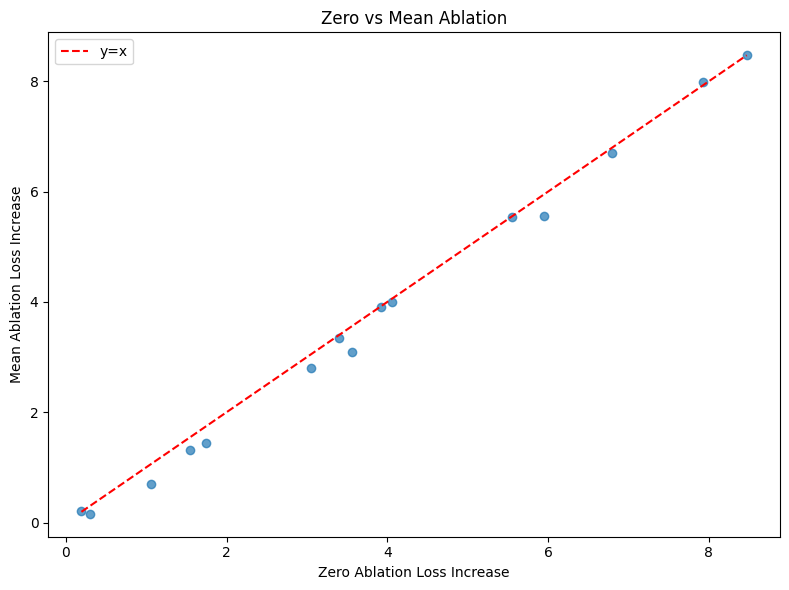

In [18]:
# compare ablation methods
fig, ax = plt.subplots(figsize=(8, 6))

zero_losses = results_df.filter(pl.col("ablation_method") == "zero")["loss_increase"].to_numpy()
mean_losses = results_df.filter(pl.col("ablation_method") == "mean")["loss_increase"].to_numpy()

ax.scatter(zero_losses, mean_losses, alpha=0.7)
ax.plot([min(zero_losses), max(zero_losses)], [min(zero_losses), max(zero_losses)], 'r--', label='y=x')
ax.set_xlabel("Zero Ablation Loss Increase")
ax.set_ylabel("Mean Ablation Loss Increase")
ax.set_title("Zero vs Mean Ablation")
ax.legend()

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig(f"figures/ablation_methods_{TARGET_MODEL.replace('/', '_')}.pdf", bbox_inches="tight")